In [2]:
import pandas as pd


df = pd.read_csv("./WineQT.csv")

In [4]:
df.shape

(1143, 13)

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [8]:
df.duplicated(keep=False).sum()

np.int64(0)

In [10]:
df["Id"].duplicated().sum()

np.int64(0)

In [14]:
df = df.drop(columns=["Id"])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
numeric_columns = df.select_dtypes(include=["number"]).columns
print(numeric_columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


<Axes: >

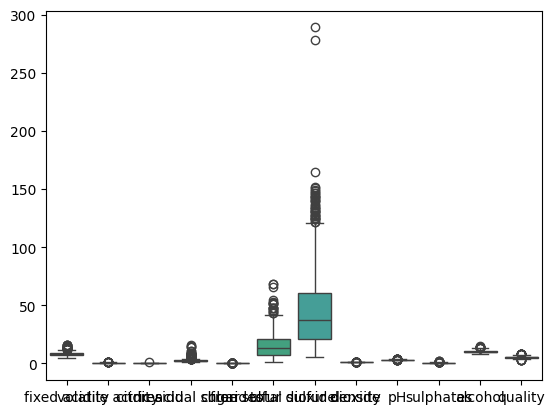

In [18]:
import seaborn as sns
sns.boxplot(data=df.select_dtypes(include=["number"]))

<Axes: >

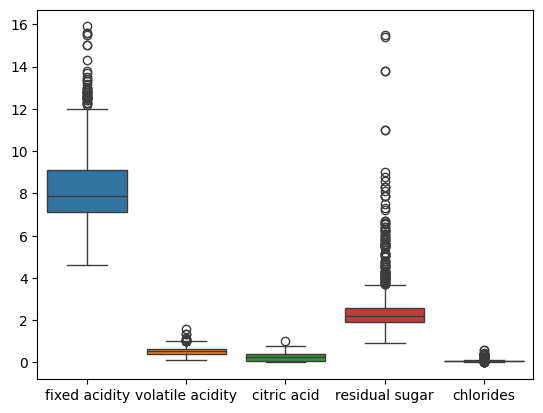

In [20]:
sns.boxplot(data=df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides' ]])

<Axes: >

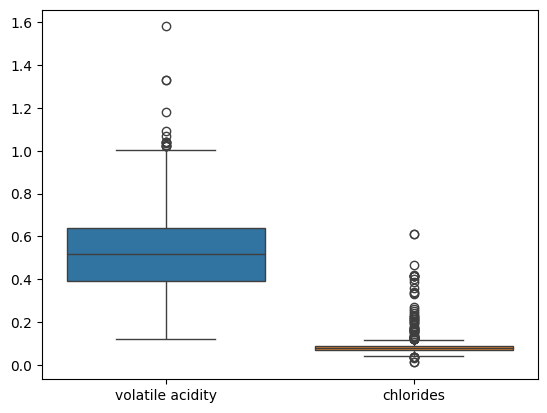

In [21]:
sns.boxplot(data=df[['volatile acidity', 'chlorides' ]])

<Axes: >

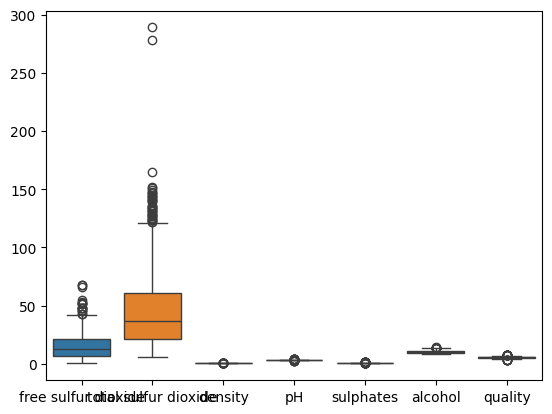

In [22]:
sns.boxplot(data=df[['free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality' ]])

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer


def replace_outliers(x,col):
    x = x.copy()
    q1=x[col].quantile(0.25)
    q3=x[col].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper = q3+1.5*IQR
    mask=(x[col]<lower) | (x[col]>upper)
    x.loc[mask,col]=np.nan
    imputer=SimpleImputer(strategy="median")
    x[col]=imputer.fit_transform(x[[col]])
    return x

df1= replace_outliers(df,"residual sugar")



KeyError: 'sulfur dioxide'

In [31]:
df1= replace_outliers(df,"free sulfur dioxide")

<Axes: >

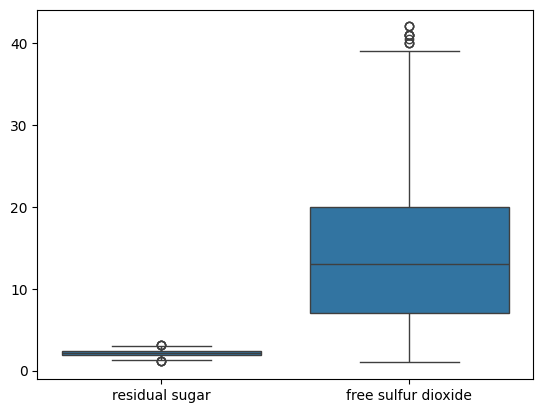

In [ ]:
sns.boxplot(data=df1[["residual sugar" ]])
sns.boxplot(data=df1[["free sulfur dioxide" ]])


<Axes: >

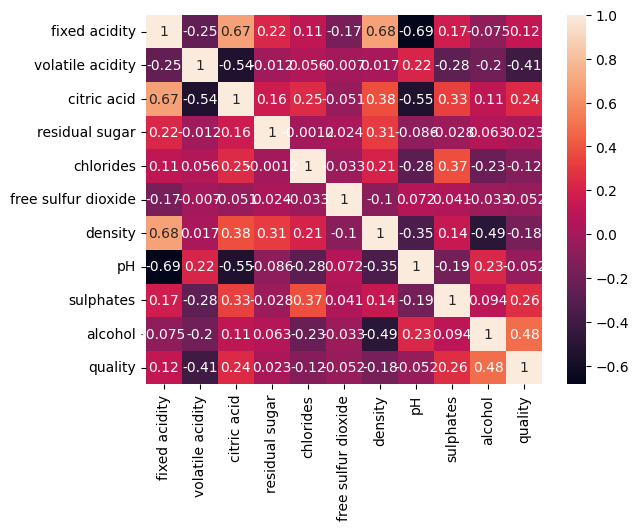

In [42]:
sns.heatmap(df1.corr(numeric_only=True),annot=True)

<Axes: xlabel='citric acid', ylabel='fixed acidity'>

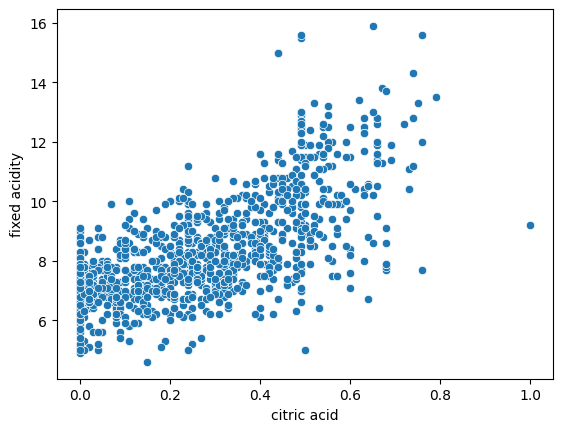

In [38]:
sns.scatterplot(data = df1, x="citric acid",y ="fixed acidity")

<Axes: xlabel='total sulfur dioxide', ylabel='free sulfur dioxide'>

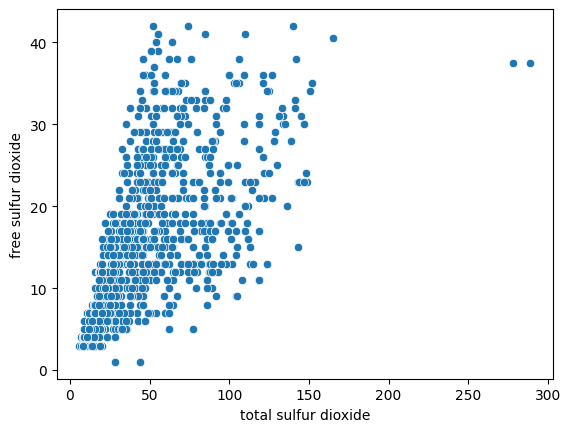

In [39]:
sns.scatterplot(data = df1, x="total sulfur dioxide",y ="free sulfur dioxide")

In [40]:
df1=df1.drop(columns=["total sulfur dioxide"])

<Axes: xlabel='density', ylabel='fixed acidity'>

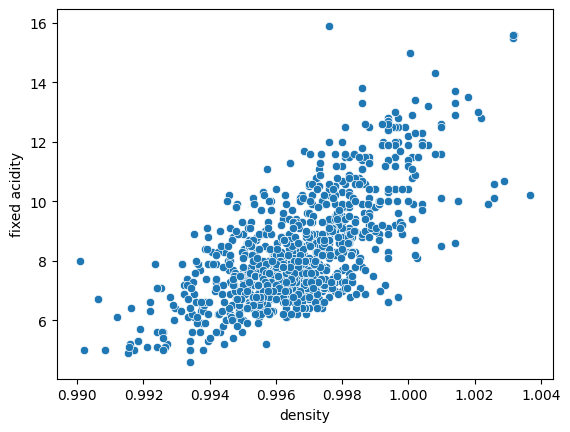

In [41]:
sns.scatterplot(data = df1, x="density",y ="fixed acidity")

In [78]:
#pipeline
from sklearn.model_selection import train_test_split


x=df1.drop("quality",axis=1)
y=df1["quality"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
numeric_cols =x.select_dtypes(include=["number"]).columns
print(numeric_cols)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'density', 'pH', 'sulphates',
       'alcohol'],
      dtype='object')


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline


numeric_transformer = Pipeline([
    ("Imputer",SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2,include_bias=False)),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers =[
        ("num", numeric_transformer,numeric_cols)
    ],
    remainder="drop"
)

pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model", LinearRegression())
])

In [90]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import MinMaxScaler


param_grid = {
    "model":[Ridge(), Lasso()],
    "model__alpha":np.logspace(-4,2,20),
    "preprocessor__num__poly__degree":[1,2,3,4,5],
    "preprocessor__num__scaler":[StandardScaler(),MinMaxScaler()]
}

In [92]:
from sklearn.model_selection import GridSearchCV, KFold


grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=KFold(n_splits=5,shuffle=True,random_state=42),
    scoring="neg_mean_squared_error"
)

In [93]:
grid.fit(x_train,y_train)

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.489e+01, tolerance: 4.703e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.748e+01, tolerance: 4.974e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model': [Ridge(), Lasso()], 'model__alpha': array([1.0000...00000000e+02]), 'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose ver

In [94]:
params = grid.best_params_
print(params)
best_model = grid.best_estimator_

{'model': Ridge(), 'model__alpha': np.float64(23.357214690901213), 'preprocessor__num__poly__degree': 2, 'preprocessor__num__scaler': StandardScaler()}


In [96]:
y_pred = best_model.predict(x_test)

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(f"RMSE: {rmse}")
mae = mean_absolute_error(y_test,y_pred)
print(f"MAE: {mae}")
r2=r2_score(y_test,y_pred)
print(f"R2: {r2}")



RMSE: 0.6197421627509314
MAE: 0.48461841223055874
R2: 0.30979516329453394


In [98]:

pipeline_ridge = Pipeline([
    ("preprocessor",preprocessor),
    ("model", Lasso())
])

In [99]:
from sklearn.model_selection import validation_curve


train_scores,val_scores=validation_curve(
    pipeline_ridge,
    x_train,
    y_train,
    param_name = "model__alpha",
    param_range = np.logspace(-3,3,10),
    cv=KFold(n_splits=5,shuffle=True,random_state=42),
    scoring="neg_mean_squared_error"
)

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.130e+00, tolerance: 4.703e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.326e+00, tolerance: 4.974e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

In [100]:
train_mean = np.mean(train_scores,axis=1)
val_mean = np.mean(val_scores,axis=1)

print(train_mean, val_mean)

[-0.37850145 -0.39372947 -0.41275615 -0.44346865 -0.67171033 -0.67171033
 -0.67171033 -0.67171033 -0.67171033 -0.67171033] [-0.43290761 -0.42255138 -0.42838268 -0.45191708 -0.67360122 -0.67360122
 -0.67360122 -0.67360122 -0.67360122 -0.67360122]


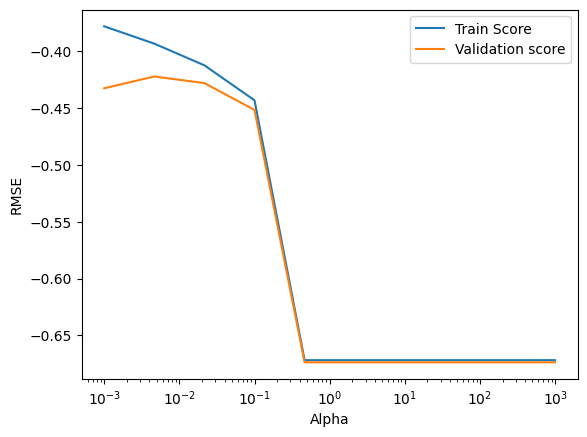

In [101]:
from matplotlib import pyplot as plt
param_range = np.logspace(-3,3,10)

plt.plot(param_range,train_mean,label="Train Score")
plt.plot(param_range, val_mean, label="Validation score")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.legend()
plt.show()